# MIPT Tutorial - Measurement-Induced Phase Transition

This tutorial demonstrates the **Measurement-Induced Phase Transition (MIPT)** in a 1D quantum circuit with random unitary gates and projective measurements.

## What is MIPT?

The MIPT arises from a competition between two processes:

1. **Unitary evolution** (Haar random gates): Creates entanglement between qubits
2. **Projective measurements** (Z-basis): Destroys entanglement locally

Depending on the measurement rate, the system exhibits two distinct phases:

- **Volume-law phase** (p < p_c ≈ 0.16): Entanglement entropy scales with system size S ~ L
- **Area-law phase** (p > p_c ≈ 0.16): Entanglement entropy remains constant S ~ const
- **Critical point** (p ≈ p_c): Logarithmic scaling S ~ log(L)

## Measurement vs Reset: A Critical Distinction


- **Measurement(:Z)**: Pure projective measurement - qubit collapses to |0⟩ or |1⟩ and stays there

## Circuit Structure

Each timestep consists of three operations:

1. `Bricklayer(:odd)` - Haar random gates on pairs (1,2), (3,4), (5,6), ...
2. `Bricklayer(:even)` - Haar random gates on pairs (2,3), (4,5), (L,1), ...
3. Z-measurements - Each site measured with probability p using `Measurement(:Z)`

This Bricklayer pattern ensures all qubits are entangled before measurements occur.

## Setup

First, activate the project environment and import QuantumCircuitsMPS:

In [1]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Luxor

  Activating project at `~/personal/QuantumCircuitsMPS.jl`
[ Info: Precompiling QuantumCircuitsMPS [ed2bb82c-fd6e-4581-809a-ddc7a64756b9](cache misses: include_dependency fsize change (1), mismatched flags (9))
[ Info: Precompiling QuantumCircuitsMPS [ed2bb82c-fd6e-4581-809a-ddc7a64756b9] (cache misses: include_dependency fsize change (2), mismatched flags (18))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling QuantumCircuitsMPSLuxorExt [a0b03d75-ac94-5677-b0ab-883b2638f7aa](cache misses: wrong dep version loaded (1), mismatched flags (7))
[ Info: Precompiling QuantumCircuitsMPSLuxorExt [a0b03d75-ac94-5677-b0ab-883b2638f7aa] (cache misses: wrong dep version loaded (2), mismatched flags (14))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Section 1: Setup and Parameters

Define the system parameters for the MIPT simulation:

In [2]:
# Define system parameters
const L = 8                   # System size (number of qubits)
const bc = :periodic           # Boundary conditions
const n_steps = 50             # Total timesteps for simulation (used in simulate!(n_circuits=n_steps))
const p = 0.15                 # Measurement probability (near critical p_c ≈ 0.16)
const cut = L ÷ 2              # Entanglement cut position

println("=" ^ 70)
println("MIPT Example - Measurement-Induced Phase Transition")
println("=" ^ 70)
println()
println("Parameters:")
println("  L = $L (system size)")
println("  bc = $bc (boundary conditions)")
println("  n_steps = $n_steps (circuit timesteps)")
println("  p = $p (measurement probability)")
println("  cut = $cut (entanglement cut position)")
println()

MIPT Example - Measurement-Induced Phase Transition

Parameters:
  L = 8 (system size)
  bc = periodic (boundary conditions)
  n_steps = 50 (circuit timesteps)
  p = 0.15 (measurement probability)
  cut = 4 (entanglement cut position)



## Section 2: Building the MIPT Circuit

The circuit implements the standard MIPT protocol with Bricklayer unitary gates followed by stochastic measurements.

**Key API Features**:
- `apply!(c, gate, geometry)` - Apply deterministic gates
- `apply_with_prob!(c; rng=:gates_spacetime, outcomes=[...])` - Apply stochastic operations
- `Bricklayer(:odd)` and `Bricklayer(:even)` - Alternating brick patterns for full connectivity

In [3]:
println("Building MIPT circuit...")
println()

# Build circuit with n_steps=1 (one timestep per circuit execution)
# We'll run this circuit n_steps times using simulate!(n_circuits=n_steps)
circuit = Circuit(L=L, bc=bc, n_steps=2, p=p) do c
    # Even pairs + measure
    # Parameters accessed via c.params[:key] for self-contained circuits
    apply!(c, HaarRandom(), Bricklayer(:even))
    apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
        (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
    ])
    # Odd pairs + measure  
    apply!(c, HaarRandom(), Bricklayer(:odd))
    apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
        (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
    ])
end

println("✓ Circuit built successfully")
println("  Circuit n_steps: $(circuit.n_steps) (timesteps per circuit run)")
println("  System size: $(circuit.L) qubits")
println("  Boundary conditions: $(circuit.bc)")
println()

Building MIPT circuit...

✓ Circuit built successfully
  Circuit n_steps: 2 (timesteps per circuit run)
  System size: 8 qubits
  Boundary conditions: periodic


  Circuit n_steps: 2 (timesteps per circuit run)
  System size: 8 qubits
  Boundary conditions: periodic



### Circuit Visualization

Visualize the circuit structure to inspect the gate layout before running the simulation:

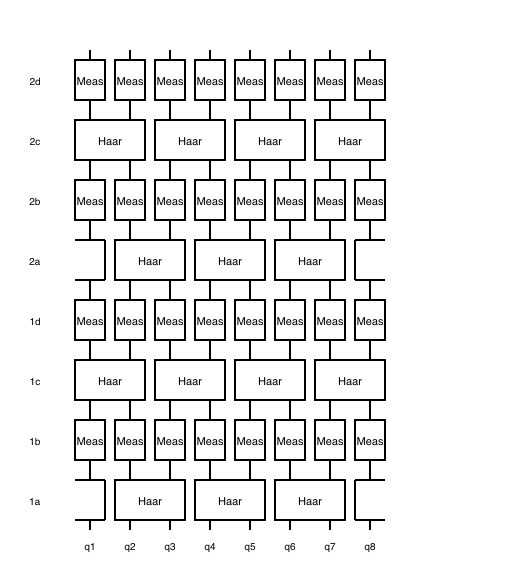

In [4]:
plot_circuit(circuit; gates_spacetime=42)

## Section 3: Simulation with Entanglement Tracking

We track the **entanglement entropy** at the central cut (position L÷2) to monitor the competition between:
- Unitary entanglement generation
- Measurement-induced disentanglement

The `EntanglementEntropy` observable computes the von Neumann entropy across a bipartite cut:

$$S = -\sum_i \lambda_i^2 \log(\lambda_i^2)$$

where $\lambda_i$ are the Schmidt coefficients from the SVD of the MPS bond.

In [4]:
println("Running simulation...")
println()

# Create simulation state with RNG registry
state = SimulationState(
    L=L,
    bc=bc,
    rng=RNGRegistry(gates_spacetime=42, born_measurement=1, gates_realization=2)
)

# Initialize to product state |0⟩⊗L
initialize!(state, ProductState(binary_int=0))

# Track entanglement entropy at the central cut
track!(state, :entropy => EntanglementEntropy(; cut=cut))

# Run simulation: execute circuit n_steps times (n_circuits=n_steps)
# The circuit has n_steps=1, so we run it n_steps times to get n_steps total timesteps
simulate!(circuit, state; n_circuits=n_steps, record_when=:every_step)

# Extract entropy values from state
entropy_vals = state.observables[:entropy]

println("✓ Simulation complete")
println("  Recorded $(length(entropy_vals)) entropy values")
println()

Running simulation...

✓ Simulation complete
  Recorded 50 entropy values


  Recorded 50 entropy values



In [5]:
entropy_vals

50-element Vector{Float64}:
  3.2034265038149497e-16
  0.9456859288334469
  0.7975373155742285
  3.189050971091868e-30
  1.2915670171440095
  1.2995849318068289
  1.381483972222853
  0.7855139715898798
  1.262686035601259
  1.3599656126420459
  1.1497716737486525
  1.5025497822974112
 -6.406853007629805e-16
  ⋮
  1.4643772069073449
  1.5641308189285863
  1.3570017153472758
  1.2352691864388068
  1.4829180782140883
  1.3125881924314444
  1.2445554505118146
  1.3890548228763762
  1.7159482489339442
  1.2628036104733298
  1.4736776901598363
  1.4604209983423382

## Section 4: Results and Analysis

Print the entanglement entropy evolution at regular intervals to observe the dynamics:

In [6]:
println("Entanglement Entropy Evolution:")
println("-" ^ 70)

# Print entropy at every 10 steps
for t in 1:n_steps
    if t % 10 == 0 || t == n_steps
        println("Step $t: Entanglement entropy = $(Printf.@sprintf("%.6f", entropy_vals[t]))")
    end
end

println()
println("=" ^ 70)
println("Simulation complete!")
println()
println("Physical Interpretation:")
println("  - At p=0.15 (near critical p_c ≈ 0.16), entropy shows non-trivial dynamics")
println("  - Volume-law phase (p < p_c): S ~ L (high entanglement)")
println("  - Area-law phase (p > p_c): S ~ const (low entanglement)")
println("  - Critical point (p ≈ p_c): S ~ log(L)")
println("=" ^ 70)

Entanglement Entropy Evolution:
----------------------------------------------------------------------
Step 10: Entanglement entropy = 0.528586
Step 20: Entanglement entropy = 0.590629
Step 30: Entanglement entropy = 0.415195
Step 40: Entanglement entropy = 0.578209
Step 50: Entanglement entropy = 0.302217

Simulation complete!

Physical Interpretation:
  - At p=0.15 (near critical p_c ≈ 0.16), entropy shows non-trivial dynamics
  - Volume-law phase (p < p_c): S ~ L (high entanglement)
  - Area-law phase (p > p_c): S ~ const (low entanglement)
  - Critical point (p ≈ p_c): S ~ log(L)


## Exercises

Try modifying the measurement rate `p` to explore different phases:

1. **Deep volume-law phase**: Set `p = 0.05` (low measurement rate)
   - Expected: Entropy grows and saturates at high value ~ L
   - Unitary dynamics dominate

2. **Near-critical** (current): `p = 0.15`
   - Expected: Non-trivial dynamics with intermediate entropy
   - Competition between unitary and measurement

3. **Area-law phase**: Set `p = 0.30` (high measurement rate)
   - Expected: Entropy remains low ~ const
   - Measurements suppress entanglement

**Challenge**: Plot the entanglement entropy evolution for all three values of `p` on the same graph. What differences do you observe?

**Hint**: You can access the entropy values via `state.observables[:entropy]`.